In [1]:
from pyspark.sql.functions import col, when, count, avg
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
spark = SparkSession.builder \
    .appName("temporal_spatial") \
    .master("spark://spark-master:7077") \
    .getOrCreate()

print("Spark initialized.")

Spark initialized.


In [3]:
df = spark.read.parquet("hdfs://namenode:9000/data/processed/chicago_crimes_clean.parquet")

In [4]:
# 基于犯罪发生的小时（crime_hour）构造夜间标记 is_night
# 夜间定义为：
# - 22:00 至 23:59
# - 00:00 至 05:59
df_time_space = df.withColumn(
    "is_night",
    (col("crime_hour") >= 22) | (col("crime_hour") < 6)
)

district_night_profile = (
    df_time_space
    # 按 Police District 分组
    .groupBy("District")
    .agg(
        # 该警区的犯罪总数
        count("*").alias("total_crimes"),
        # 夜间犯罪比例：
        # is_night=True  → 1
        # is_night=False → 0
        # avg(0/1) 即为夜间犯罪所占比例
        avg(when(col("is_night"), 1).otherwise(0)).alias("night_crime_ratio")
    )
    # 按夜间犯罪比例从高到低排序
    .orderBy(col("night_crime_ratio").desc())
    # 转为 Pandas DataFrame（District 数量很小，安全）
    .toPandas()
)

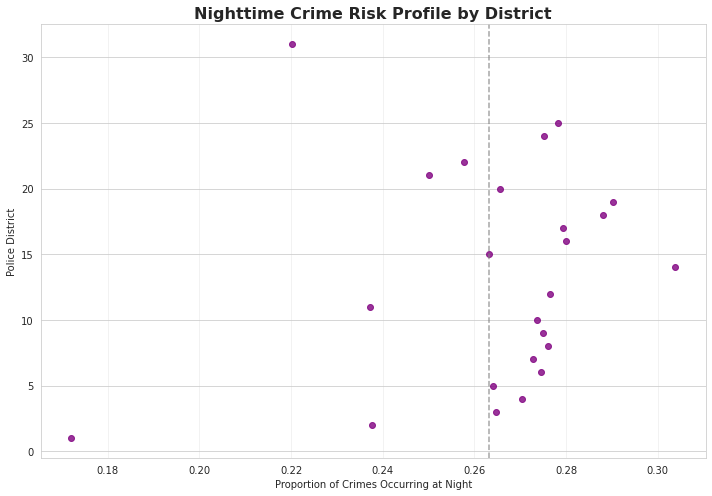

Saved: temporal_spatial.png


<Figure size 432x288 with 0 Axes>

In [5]:
# 再次按夜间犯罪比例排序（用于可视化）
district_night_profile_sorted = district_night_profile.sort_values(
    "night_crime_ratio"
)

plt.figure(figsize=(10, 7))
plt.scatter(
    district_night_profile_sorted["night_crime_ratio"],
    district_night_profile_sorted["District"],
    color="purple",
    alpha=0.8
)

avg_ratio = district_night_profile["night_crime_ratio"].mean()
plt.axvline(avg_ratio, color="gray", linestyle="--", alpha=0.7)

plt.title("Nighttime Crime Risk Profile by District",
          fontsize=16, fontweight="bold")
plt.xlabel("Proportion of Crimes Occurring at Night")
plt.ylabel("Police District")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig("/home/jovyan/notebooks/outputs/temporal_spatial.png", dpi=300)
print("Saved: temporal_spatial.png")

In [6]:
spark.stop()